In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from group_sae.utils import load_cluster_map

### Parameters

In [2]:
K = 4
concodance_folder = f"/root/group-sae/feature_concordance/concordance/pythia-160m/{K}"

In [3]:
concordance_matrix = np.load(os.path.join(concodance_folder, "concordance.npy"))

Text(50.722222222222214, 0.5, 'Baseline layer')

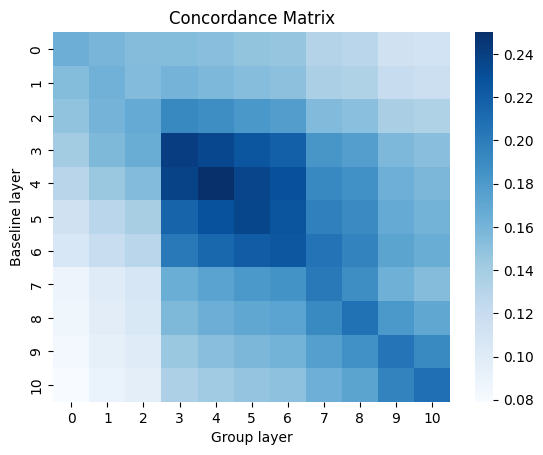

In [4]:
sns.heatmap(concordance_matrix, cmap="Blues")
plt.title("Concordance Matrix")
plt.xlabel("Group layer")
plt.ylabel("Baseline layer")

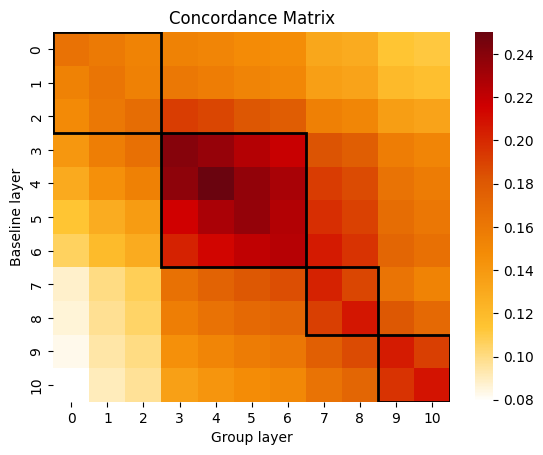

In [6]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

palette = ["#FFFFFF", "#FFC533", "#f48c06", "#DD5703", "#d00000", "#6A040F"]
cmap = LinearSegmentedColormap.from_list("paper", palette)

# Plot the heatmap.
sns.heatmap(concordance_matrix, cmap=cmap)
plt.title("Concordance Matrix")
plt.xlabel("Group layer")
plt.ylabel("Baseline layer")

# Load your cluster map.
cluster_map = load_cluster_map("160m")
# Assume K is defined (or choose one of the keys) so that cluster_map[str(K)] gives
# an array-like of cluster labels in the order of your heatmap rows.
# For instance, if K is already set:
#   cluster_labels = cluster_map[str(K)]
# Otherwise, choose a key, e.g., K = list(cluster_map.keys())[0]

# Get a numeric assignment for each row.
# For example, given:
#   np.unique(cluster_map[str(K)], return_inverse=True)
# returns (unique_labels, inverse_array)
unique_labels, inv = np.unique(cluster_map[str(K)], return_inverse=True)
# inv is an array like: array([1, 1, 1, 0, 0, 0, 0, 2, 2, 3, 3])
# which tells you that rows 0-2 are one cluster, rows 3-6 are another, etc.
n = len(inv)

# Find the contiguous blocks of rows that share the same cluster label.
blocks = []
start = 0
for i in range(1, n):
    if inv[i] != inv[i - 1]:
        blocks.append((start, i))
        start = i
blocks.append((start, n))  # add the final block

ax = plt.gca()
# Draw a square (a Rectangle with equal width and height) for each contiguous cluster block.
# This example assumes that the heatmap is square and the ordering for rows and columns are the same.
for start, end in blocks:
    width = end - start
    # In the heatmap, cell boundaries are at integer positions.
    # The rectangle is drawn with (x, y) as the top-left corner.
    rect = patches.Rectangle((start, start), width, width, fill=False, edgecolor="black", lw=2)
    ax.add_patch(rect)

plt.show()